## Interpretabilidad del modelo

En este apartado se analiza la interpretabilidad del modelo XGBoost, seleccionado previamente como el modelo con mejor rendimiento global.

Dado que el problema se enmarca en un contexto clínico, no es suficiente con maximizar métricas predictivas, sino que resulta fundamental comprender qué variables influyen en la predicción del reingreso hospitalario y cómo lo hacen.

Para ello, se analizan las variables más importantes según el modelo y se complementa el análisis con técnicas de interpretabilidad global, permitiendo identificar patrones relevantes desde una perspectiva médica y analítica.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

c:\Users\pedro\anaconda3\envs\tfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Carga de datos y modelo

In [6]:
xgb_model = joblib.load("../data/models/xgb_model.pkl")
rf_model = joblib.load("../data/models/rf_model.pkl")
log_model = joblib.load("../data/models/log_model.pkl")

train_df = pd.read_csv("../data/processed/train_preprocessed.csv")
test_df  = pd.read_csv("../data/processed/test_preprocessed.csv")

X_train = train_df.drop("readmit_30", axis=1)
y_train = train_df["readmit_30"]

X_test = test_df.drop("readmit_30", axis=1)
y_test = test_df["readmit_30"]

### Importancia de variables (XGBoost)

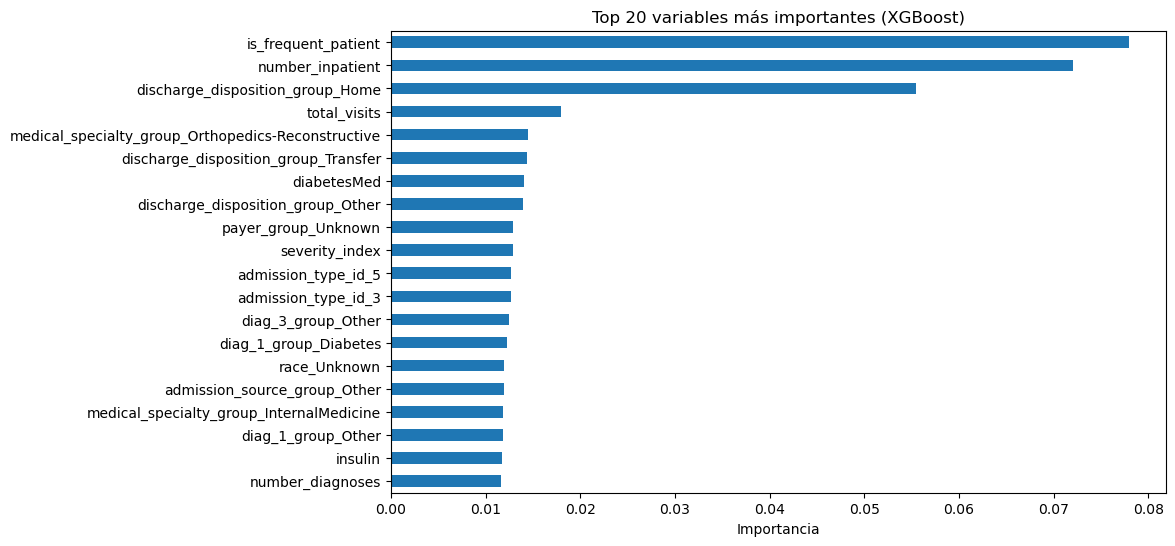

In [7]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 20 variables más importantes (XGBoost)")
plt.xlabel("Importancia")
plt.show()

## Interpretación de importancia de variables

El gráfico de importancia de variables permite identificar los factores más influyentes en la predicción del reingreso hospitalario.

Se observa que las variables más relevantes están relacionadas principalmente con tres bloques:

- Utilización previa de recursos sanitarios (número de ingresos previos, visitas urgentes y hospitalizaciones anteriores)
- Intensidad del tratamiento durante la estancia hospitalaria (medicación, procedimientos y pruebas de laboratorio)
- Variables clínicas asociadas a la complejidad del paciente (diagnósticos y severidad)

Este resultado es coherente con la literatura médica, donde el historial de utilización sanitaria y la carga clínica del paciente son predictores clave de reingreso.

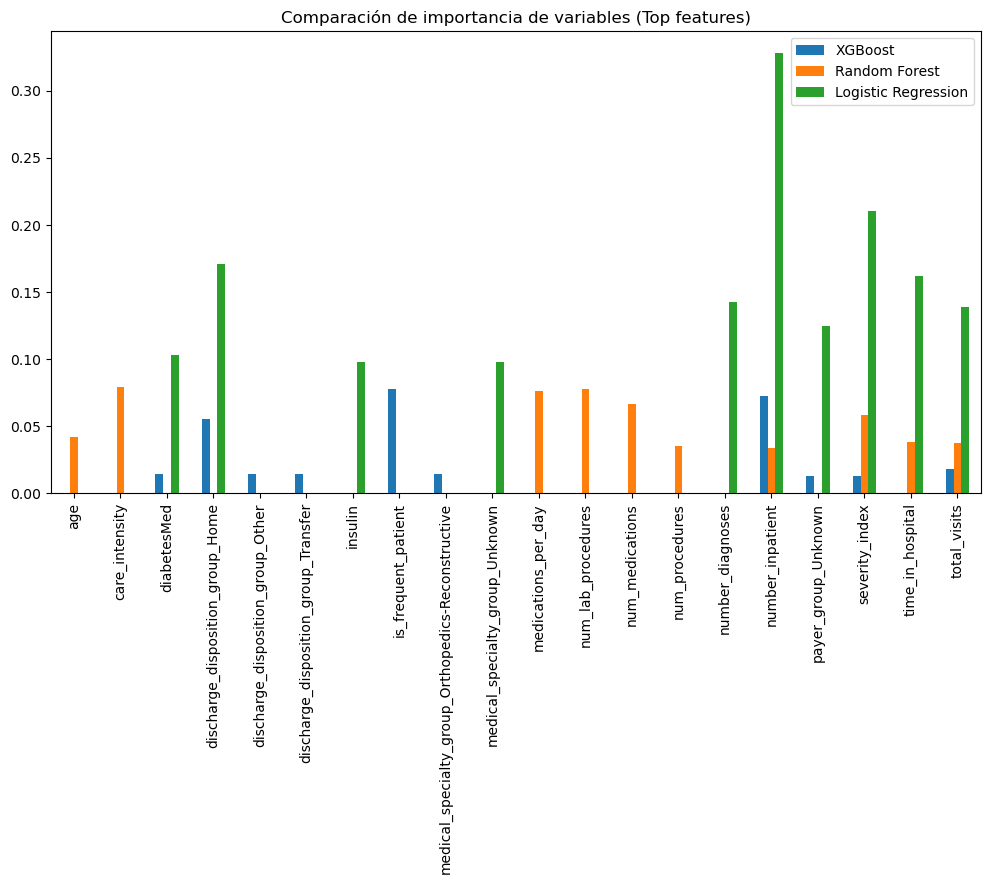

In [9]:
top_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
top_rf  = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
top_lr  = pd.Series(abs(log_model.named_steps['classifier'].coef_[0]), index=X_train.columns).sort_values(ascending=False).head(10)

compare_df = pd.DataFrame({
    "XGBoost": top_xgb,
    "Random Forest": top_rf,
    "Logistic Regression": top_lr
})

compare_df.plot(kind="bar", figsize=(12,6))
plt.title("Comparación de importancia de variables (Top features)")
plt.show()

La importancia de variables difiere entre modelos debido a sus distintos mecanismos de aprendizaje. Mientras que los modelos basados en árboles capturan relaciones no lineales, la regresión logística refleja relaciones lineales ponderadas. Por ello, la comparación directa debe interpretarse con cautela y la complementaremos con SHAP.

## Interpretabilidad avanzada (SHAP)

on el objetivo de dotar al modelo XGBoost de una capa de interpretabilidad robusta, se ha aplicado la metodología SHAP (*SHapley Additive exPlanations*), la cual permite descomponer cada predicción en contribuciones individuales de las variables. A diferencia de las importancias globales basadas en árboles, SHAP proporciona una interpretación consistente desde el punto de vista teórico, basada en la teoría de juegos cooperativos, y permite analizar tanto el comportamiento global del modelo como explicaciones a nivel de instancia.

### Enfoque metodológico

Se ha utilizado un *TreeExplainer* adaptado a modelos basados en árboles, lo que garantiza eficiencia computacional y exactitud en el cálculo de los valores SHAP para XGBoost. El análisis se estructura en dos niveles:

- **Interpretación global**: identificación de las variables con mayor impacto medio absoluto sobre la predicción.
- **Interpretación local**: análisis del efecto de cada variable en predicciones individuales.

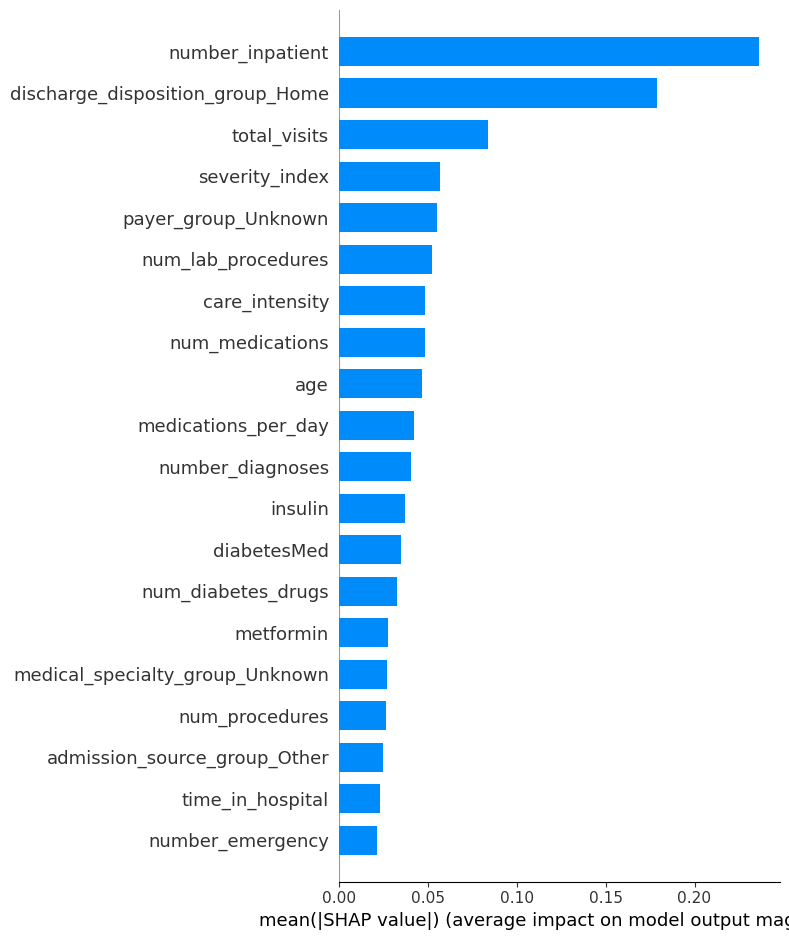

In [11]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

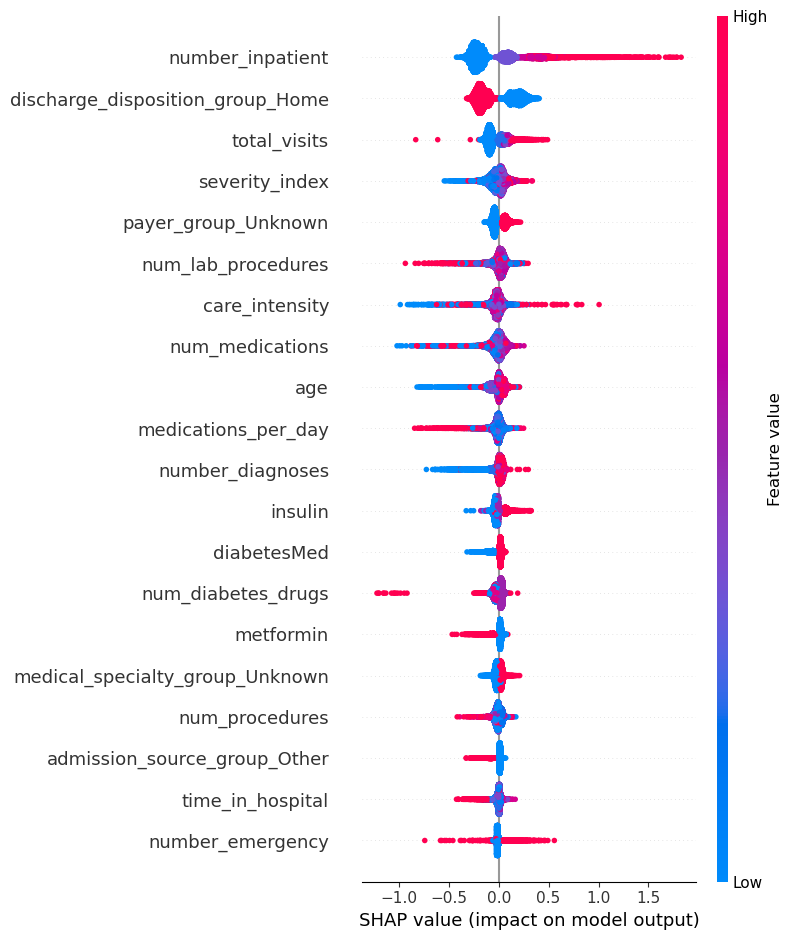

In [12]:
shap.summary_plot(shap_values, X_test)

## Interpretación global (SHAP summary plot)

El resumen global de valores SHAP permite identificar qué variables contribuyen de forma más significativa a la predicción del riesgo de reingreso hospitalario.

Se observa que las variables con mayor impacto son principalmente:

- Indicadores de utilización previa del sistema sanitario (ingresos previos, visitas a urgencias, hospitalizaciones anteriores)
- Variables relacionadas con la intensidad del episodio hospitalario (número de medicaciones, procedimientos y pruebas de laboratorio)
- Variables clínicas asociadas a la complejidad del paciente (número de diagnósticos y comorbilidades)

Este resultado es consistente con la evidencia clínica, donde el historial de uso de recursos sanitarios y la carga de enfermedad del paciente son predictores clave de reingreso.

## Interpretación del efecto de las variables

El análisis no solo permite identificar variables importantes, sino también entender la dirección del efecto:

- Valores elevados en variables como `number_inpatient`, `number_emergency` o `time_in_hospital` incrementan la probabilidad predicha de reingreso.
- Variables asociadas a menor utilización previa del sistema sanitario tienden a reducir el riesgo estimado.
- En variables clínicas, la presencia de mayor complejidad (más diagnósticos o tratamientos intensivos) se asocia con un incremento del riesgo.

Este comportamiento refleja coherencia clínica, ya que pacientes con mayor historial de atención médica suelen presentar patologías más complejas o mal controladas.

## Interpretación clínica

Desde una perspectiva sanitaria, los resultados obtenidos mediante SHAP refuerzan la validez del modelo en términos de plausibilidad clínica:

- El modelo identifica correctamente la **cronicidad y complejidad del paciente** como factores de riesgo.
- Se observa una fuerte dependencia del modelo respecto a la **historia de utilización de recursos sanitarios**, lo cual es coherente con patrones conocidos de reingreso hospitalario.
- Las variables administrativas y de proceso asistencial también contribuyen significativamente, lo que sugiere que parte del riesgo de reingreso está condicionado por factores del sistema sanitario además de los clínicos.

## Conclusión

El análisis mediante SHAP permite validar el modelo XGBoost no solo desde una perspectiva predictiva, sino también explicativa. La coherencia entre las variables identificadas como relevantes y la evidencia clínica existente refuerza la fiabilidad del modelo y su potencial aplicabilidad en entornos sanitarios reales.

En conjunto, este análisis aporta transparencia al modelo, un requisito fundamental en aplicaciones de inteligencia artificial en salud, donde la interpretabilidad es tan relevante como el rendimiento predictivo.